In [9]:
from xrss.dataloader import XRayDataset, show_images_and_bboxes
from xrss.models import TwoStageDetector
from xrss.utils import evaluate_score
import numpy as np
import os

In [ ]:
yaml_file = "../xray_data/data.yaml"

train_dataset = XRayDataset(yaml_file, split="train", resize=False)
val_dataset = XRayDataset(yaml_file, split="val", resize=False)

Train: 4200 images
Test: 900 images


In [ ]:
detector = TwoStageDetector(
    nc=6,
    stage1_threshold=0.45,
    n_estimators=200,
)

detector.train(train_dataset, validate=True)

Training TwoStageDetector on 4200 images...


Extracting features:   0%|          | 0/4200 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 4200/4200 [10:57<00:00,  6.39it/s]



Data collected:
  Object samples: 6211
  Background samples: 282133
  Object class distribution: Counter({np.int64(2): 1310, np.int64(1): 1115, np.int64(3): 1033, np.int64(5): 965, np.int64(4): 931, np.int64(0): 857})

Learned class constraints:
  Class 0: area=[0.0668, 0.3986], aspect=[0.49, 3.46]
  Class 1: area=[0.0169, 0.2635], aspect=[0.26, 6.33]
  Class 2: area=[0.0134, 0.1247], aspect=[0.39, 3.55]
  Class 3: area=[0.0148, 0.2090], aspect=[0.27, 5.36]
  Class 4: area=[0.0388, 0.1716], aspect=[0.58, 2.78]
  Class 5: area=[0.0028, 0.0795], aspect=[0.26, 5.78]

STAGE 1: Training Object vs Background classifier
Undersampled background: 282133 -> 15000
Stage 1 training: 21211 samples
Stage 1 CV Accuracy: 0.921 (+/- 0.002)

STAGE 2: Training Object Class classifier
Stage 2 training: 6211 samples across 6 classes
Stage 2 CV Accuracy: 0.826 (+/- 0.051)

Training complete!


Displaying sample images with ground truth bounding boxes:


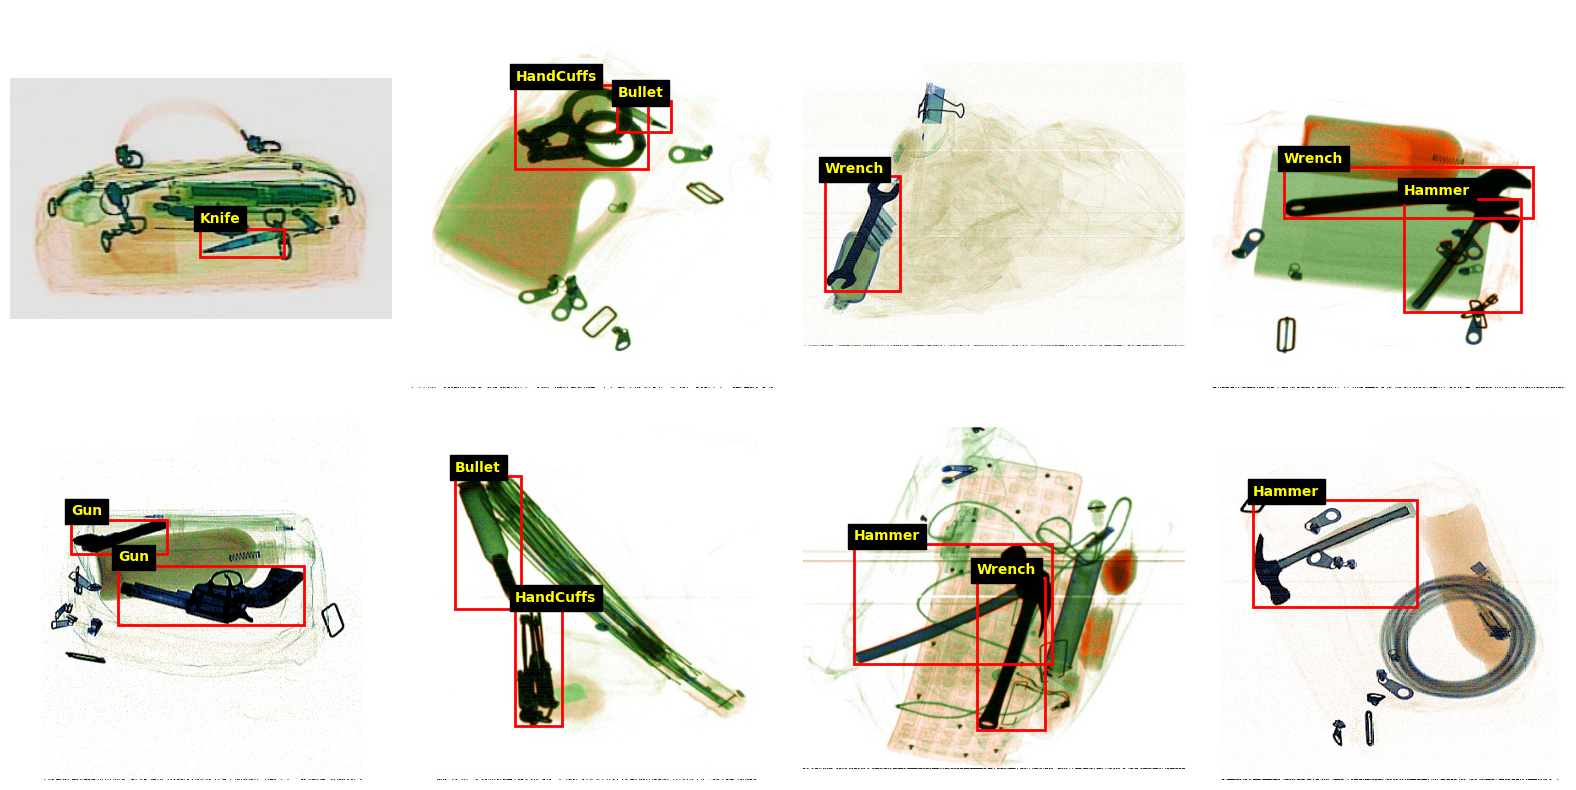

Displaying sample images with predicted bounding boxes:


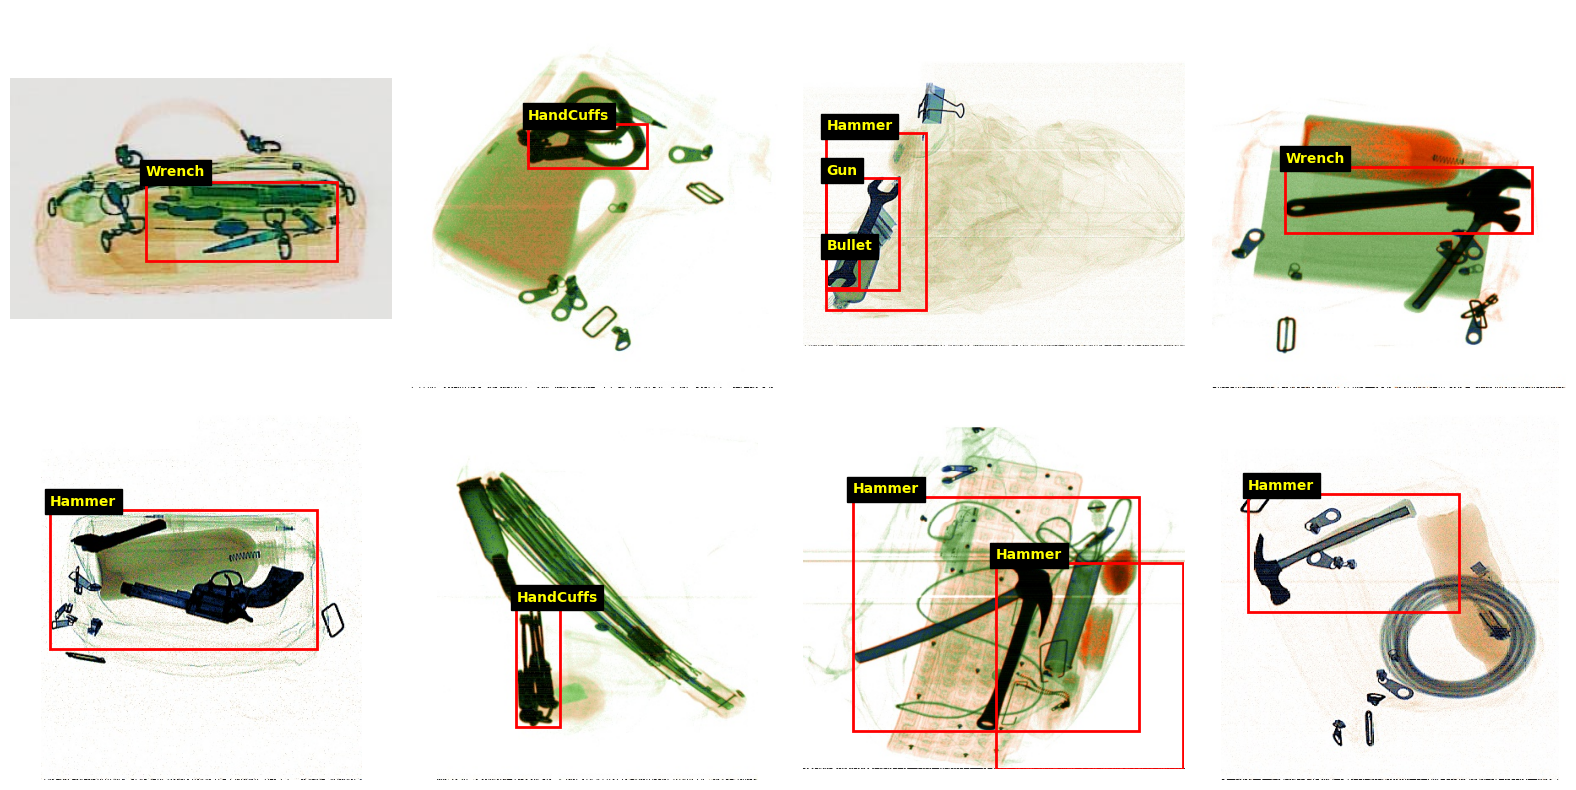

In [ ]:
model = detector
indexes = list(range(8))

images = [val_dataset[i][0] for i in indexes]
labels = [val_dataset[i][1] for i in indexes]

print("Displaying sample images with ground truth bounding boxes:")
show_images_and_bboxes(val_dataset, images, labels, cols=4)

preds = []
for img in images:
    boxes = model.detect(img)

    preds.append(boxes)

print("Displaying sample images with predicted bounding boxes:")
show_images_and_bboxes(val_dataset, images, preds, cols=4)

In [ ]:
score = evaluate_score(detector, val_dataset)

 80%|███████▉  | 718/900 [14:17<04:30,  1.49s/it]

In [ ]:
score